In [1]:
from desc.examples import get
from desc.grid import LinearGrid
from desc.integrals import Bounce2D
import numpy as np
eq = get("precise_QA")
rho=0.3
theta = Bounce2D.compute_theta(eq, X=32, Y=64, rho=rho)
grid = LinearGrid(rho=rho, M=eq.M_grid, N=eq.N_grid, NFP=eq.NFP, sym=False)
alpha = np.array([0, 0.5])
data0 = eq.compute("adiabatic J", grid=grid, theta=theta, Y_B=64, num_transit=3, num_quad=32, num_pitch=31, alpha=alpha)
data_full = grid.compress(data0["adiabatic J"])
print(f"J at rho={rho}: {data_full}")

J at rho=0.3: [[[0.00170218 0.00513917 0.00867    0.01221314 0.01575197 0.01929116
   0.02284447 0.02642564 0.03004209 0.03369374 0.03737846 0.04109422
   0.04484012 0.04861632 0.05242416 0.05626682 0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.        ]
  [0.00174864 0.00518086 0.00867054 0.01219277 0.01573681 0.01929455
   0.02285334 0.02640915 0.0299709  0.03354968 0.03715397 0.04079486
   0.0444857  0.04823431 0.05204469 0.05592236 0.05986339 0.06385536
   0.06789281 0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.        ]]]


In [2]:
import desc
import matplotlib.pyplot as plt
# eq = desc.examples.get("precise_QA")
eq = desc.io.load("/Users/rogeriojorge/local/GX_stellarator_zenodo/data_generation_and_analysis/20241122-01-QUASR/20241122-01-031_QUASR_finite_beta_equilibria_with_maxF_below_threshold_and_enough_iota_flux_tubes/QUASR_finiteBeta_000652.h5")
nalpha = 7
nzeta = 200
rho = 0.5
grid = desc.grid.Grid.create_meshgrid([rho, np.linspace(0, 2*np.pi, nalpha), np.linspace(0, 2*np.pi/eq.compute("iota")["iota"][0], nzeta)], coordinates="raz")
modB_temp = eq.compute("|B|", grid=grid)["|B|"]
modB = grid.meshgrid_reshape(modB_temp, "raz")[0]

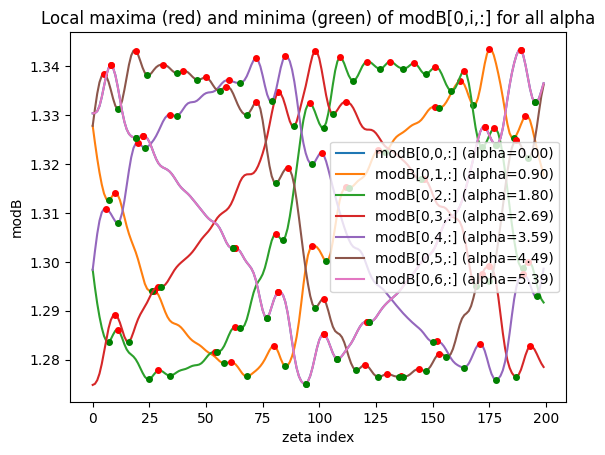

In [3]:
from scipy.signal import find_peaks
all_peaks_max = [find_peaks( modB[i, :])[0] for i in range(nalpha)]
all_peaks_min = [find_peaks(-modB[i, :])[0] for i in range(nalpha)]

for i in range(nalpha):
    plt.plot(modB[i], label=f"modB[0,{i},:] (alpha={i*2*np.pi/nalpha:.2f})")
    plt.plot(all_peaks_max[i], modB[i, all_peaks_max[i]], "ro", markersize=4)
    plt.plot(all_peaks_min[i], modB[i, all_peaks_min[i]], "go", markersize=4)
plt.title("Local maxima (red) and minima (green) of modB[0,i,:] for all alpha")
plt.xlabel("zeta index")
plt.ylabel("modB")
plt.legend()

In [ ]:
all_peaks_max = [find_peaks( modB[i, :])[0] for i in range(nalpha)]
all_peaks_min = [find_peaks(-modB[i, :])[0] for i in range(nalpha)]
stds_max_within_modB_normalized = np.array([np.std(modB[i, peaks])/np.mean(modB[i,:]) for i, peaks in enumerate(all_peaks_max)])
stds_min_within_modB_normalized = np.array([np.std(modB[i, peaks])/np.mean(modB[i,:]) for i, peaks in enumerate(all_peaks_min)])
stds_max_across_modB_normalized = np.std(np.max(modB,axis=1)/np.mean(modB,axis=1))
stds_min_across_modB_normalized = np.std(np.min(modB,axis=1)/np.mean(modB,axis=1))
combined_stds_max_modB_normalized = np.mean(stds_max_within_modB_normalized) + stds_max_across_modB_normalized
combined_stds_min_modB_normalized = np.mean(stds_min_within_modB_normalized) + stds_min_across_modB_normalized
print(f"Combined stds max modB normalized: {combined_stds_max_modB_normalized:.3f}")
print(f"Combined stds min modB normalized: {combined_stds_min_modB_normalized:.3f}")

Combined stds max modB normalized: 0.019
Combined stds min modB normalized: 0.018


In [ ]:
nalpha = 7
num_pitch = 31
rho = 0.5
eq = desc.examples.get("precise_QA")
# eq = desc.io.load("/Users/rogeriojorge/local/GX_stellarator_zenodo/data_generation_and_analysis/20241122-01-QUASR/20241122-01-031_QUASR_finite_beta_equilibria_with_maxF_below_threshold_and_enough_iota_flux_tubes/QUASR_finiteBeta_000652.h5")
theta = Bounce2D.compute_theta(eq, X=32, Y=64, rho=rho)
grid = LinearGrid(rho=rho, M=eq.M_grid, N=eq.N_grid, NFP=eq.NFP, sym=False)
data0 = eq.compute(["J_s", "J_alpha", "<v_dot_grads>"], grid=grid, theta=theta, Y_B=64, num_transit=3, num_quad=32, num_pitch=num_pitch, alpha=np.linspace(0, 2*np.pi, nalpha))
dJ_ds = grid.compress(data0["J_s"])[0]
dJ_dalpha = grid.compress(data0["<v_dot_grads>"])[0]
dJ_dalpha_DESC_metric = grid.compress(data0["J_alpha"])[0]
print(f"dJ/ds at rho={rho} with shape {dJ_ds.shape}")
print(f"dJ/dalpha at rho={rho} with shape {dJ_dalpha.shape}")
print(f"dJ/dalpha DESC metric at rho={rho} = {dJ_dalpha_DESC_metric}")

dJ/ds at rho=0.5 with shape (7, 31)
dJ/dalpha at rho=0.5 with shape (7, 31)
dJ/dalpha DESC metric at rho=0.5 = 5.200486033253711e-05


In [20]:
print(np.sum(dJ_ds**2))
print(np.sum(dJ_dalpha**2))

21.957896727116136
1.291594640673577e-05
